In [ ]:
# Checking the installetion
!maize --help

usage: maize [-h] [--version] [-c] [-l] [-o] [-d] [-q] [--keep]
             [--config CONFIG] [--scratch SCRATCH] [--parameters PARAMETERS]
             [--log LOG] [--find-io]
             file

Flow-based graph execution engine

positional arguments:
  file                  Path to a JSON, YAML or TOML input file

options:
  -h, --help            show this help message and exit

maize:
  --version             show program's version number and exit
  -c, --check           Check if the graph was built correctly and exit
  -l, --list            List all available nodes and exit
  -o, --options         List all exposed workflow parameters and exit
  -d, --debug           Provide debugging information
  -q, --quiet           Silence all output except errors and warnings
  --keep                Keep all output files
  --config CONFIG       Global configuration file to use
  --scratch SCRATCH     Workflow scratch location
  --parameters PARAMETERS
                        Additional paramet

In [2]:
import sys
import maize
from maize.core.interface import Parameter, Output, MultiInput, Input
from maize.core.node import Node
from maize.core.workflow import Workflow
from IPython.display import display

In [23]:
class Example(Node):
    """" Example node that demonstrates how to create a custom node in Maize.
    A node that sends a string from a parameter to an output.
    """
    data: Parameter[str] = Parameter()
    out: Output[str] = Output()
    def run(self) -> Node:
        self.out.send(self.data.value)
class Taker(Node):
    """A node that receives data from an Example node and prints it."""
    inp: MultiInput[str] = MultiInput()
    def run(self):
        result = " ".join([inp.receive() for inp in self.inp])
        self.logger.info(f"Received data: {result}")

    


In [24]:
flow = Workflow(name="Example Workflow")
first_node = flow.add(Example, name="Example Node", parameters={"data": "Hello My People!"})
second_node = flow.add(Example, name="Second Node", parameters={"data": "Hello Maize Again!"})
taker = flow.add(Taker, name="Taker Node")
flow.connect(first_node.out, taker.inp)
flow.connect(second_node.out, taker.inp)
flow.check()


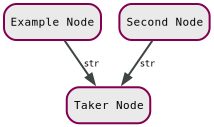

In [25]:
flow.visualize()


In [26]:
flow.execute()


2026-02-28 15:20:58,164 |     INFO | Example Workflow | 
              ___           ___                       ___           ___
             /\__\         /\  \          ___        /\  \         /\  \
            /::|  |       /::\  \        /\  \       \:\  \       /::\  \
           /:|:|  |      /:/\:\  \       \:\  \       \:\  \     /:/\:\  \
          /:/|:|__|__   /::\~\:\  \      /::\__\       \:\  \   /::\~\:\  \
         /:/ |::::\__\ /:/\:\ \:\__\  __/:/\/__/ _______\:\__\ /:/\:\ \:\__\
         \/__/~~/:/  / \/__\:\/:/  / /\/:/  /    \::::::::/__/ \:\~\:\ \/__/
               /:/  /       \::/  /  \::/__/      \:\~~\~~      \:\ \:\__\
              /:/  /        /:/  /    \:\__\       \:\  \        \:\ \/__/
             /:/  /        /:/  /      \/__/        \:\__\        \:\__\
             \/__/         \/__/                     \/__/         \/__/


2026-02-28 15:20:58,164 |     INFO | Example Workflow | Starting Maize version 0.9.4 (c) AstraZeneca 2026
2026-02-28 15:2

In [31]:

from maize.steps.io import LogResult

flow_yaml = Workflow(name="Example Yaml")
ex = flow_yaml.add(Example, name="Example Node", parameters={"data": "Hello from YAML!"})
log = flow_yaml.add(LogResult, name="Log Node")
flow_yaml.connect(ex.out, log.inp)
flow_yaml.check()
flow_yaml.visualize()
flow_yaml.to_file("example_workflow.yaml")



In [32]:
!cat example_workflow.yaml

name: Example Yaml
level: 20
nodes:
- name: Example Node
  parameters:
    data: Hello from YAML!
  type: Example
- name: Log Node
  type: LogResult
channels:
- sending:
    Example Node: out
  receiving:
    Log Node: inp
parameters: []
